### Stock Market Prediction using Stacked LSTM

In [1]:
## Using keras and Tensorflow for the model

Tiingo is a financial data platform that provides a wide range of services, primarily focused on delivering accurate, up-to-date financial and market data for investors, traders, and developers. It's particularly popular for its API, which allows users to programmatically access financial data such as historical stock prices, real-time market data, news, and more.

In [2]:
## Data Collection
import pandas as pd
import pandas_datareader as pdr
import numpy as np
import os
from dotenv import load_dotenv 
import requests
 #ye sab kuch load kr deta hai .env mein se

load_dotenv()

TINGO_API_KEY=os.getenv("TINGO_API_KEY")

In [3]:
# df = pdr.get_data_tiingo('AAPL', api_key=TINGO_API_KEY)

In [4]:

# # Tiingo API endpoint for daily data with date range
# url = "https://api.tiingo.com/tiingo/daily/AAPL/prices"

# # Your Tiingo API key
# api_key = '534f2a0bbba9dbeb5e2f927657b30e9f33d45b91'

# # Set your desired date range (for example, past 30 days)
# params = {
#     'startDate': '2015-12-01',  # Set the start date
#     'endDate': '2025-12-31',    # Set the end date
# }

# # Headers for authentication
# headers = {
#     'Authorization': f'Token {api_key}'
# }

# # Make the request to Tiingo API
# response = requests.get(url, headers=headers, params=params)

# # Check if the request was successful
# if response.status_code == 200:
#     # Convert the response data to JSON format
#     data = response.json()

#     # Convert the data to a Pandas DataFrame
#     df = pd.DataFrame(data)

#     # Display the first few rows of the DataFrame
#     df.head()
# else:
#     print(f"Error: {response.status_code}")

# df.to_csv('AAPL.csv')

In [5]:
import pandas as pd
df=pd.read_csv('AAPL.csv')
df

,Unnamed: 0,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,2015-12-01T00:00:00.000Z,117.34,118.81,116.860,118.75,34852374,26.455963,26.787396,26.347741,26.773868,139409496,0.0,1.0
1,1,2015-12-02T00:00:00.000Z,116.28,118.11,116.080,117.05,33386563,26.216971,26.629571,26.171879,26.390579,133546252,0.0,1.0
2,2,2015-12-03T00:00:00.000Z,115.20,116.79,114.220,116.55,41569509,25.973470,26.331958,25.752515,26.277847,166278036,0.0,1.0
3,3,2015-12-04T00:00:00.000Z,119.03,119.25,115.110,115.29,57776977,26.836998,26.886600,25.953178,25.993762,231107908,0.0,1.0
4,4,2015-12-07T00:00:00.000Z,118.28,119.86,117.810,118.98,32084249,26.667900,27.024133,26.561932,26.825725,128336996,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2531,2531,2025-12-24T00:00:00.000Z,273.81,275.43,272.195,272.34,17910574,273.810000,275.430000,272.195000,272.340000,17910574,0.0,1.0
2532,2532,2025-12-26T00:00:00.000Z,273.40,275.37,272.860,274.16,21521802,273.400000,275.370000,272.860000,274.160000,21521802,0.0,1.0
2533,2533,2025-12-29T00:00:00.000Z,273.76,274.36,272.350,272.69,23715213,273.760000,274.360000,272.350000,272.690000,23715213,0.0,1.0
2534,2534,2025-12-30T00:00:00.000Z,273.08,274.08,272.280,272.81,22139617,273.080000,274.080000,272.280000,272.810000,22139617,0.0,1.0


In [6]:
import pandas as pd

# convert to datetime (VERY IMPORTANT)
df['date'] = pd.to_datetime(df['date'])

# split into date and time
df['date_only'] = df['date'].dt.date
df['time'] = df['date'].dt.time

# Dropping Time column , date column
df.drop(['date','time'], axis=1, inplace=True)



No missing values , no null values , Stock market does not function on Weekends and Holidays so only 2536 values are present .

We could have taken OHLC (open , high , low , close ) but for an initial project and to keep it simple i have used only closed value as it captures all the patterns of the day.

In [7]:
df1=df.reset_index()['close']

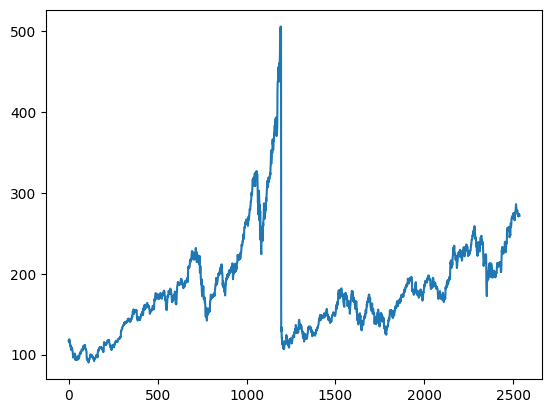

In [8]:
import matplotlib.pyplot as plt
plt.plot(df1)
plt.show()

In [9]:
## splitting dataset into train and test split  
# Preprocessing the data
training_size = int(len(df1) * 0.75)

train_data = df1[:training_size]
test_data  = df1[training_size:]
print(len(train_data), len(test_data))

1902 634


In [10]:
# scaling the data - not fit on entire data rather only on train data.
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))

train_data = scaler.fit_transform(
    np.array(train_data).reshape(-1, 1)
)

test_data = scaler.transform(
    np.array(test_data).reshape(-1, 1)
)


In [11]:
import numpy as np

def create_dataset(dataset, time_step=60):
    dataX, dataY = [], []
    
    for i in range(len(dataset) - time_step):
        X = dataset[i:(i + time_step), 0]   # past time_step values
        y = dataset[i + time_step, 0]        # next value
        
        dataX.append(X)
        dataY.append(y)
        
    return np.array(dataX), np.array(dataY)
# Creates array .

In [12]:
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)  # Train data and time step se X_train banega.
X_test, y_test   = create_dataset(test_data, time_step)

# Last 60 day data will be used to predict next day data. 
# We need to change time step according to the output or with proper reasining .

In [13]:
print(X_train.shape), print(y_train.shape)

(1842, 60)
(1842,)


(None, None)

In [14]:
# Reshape input to be [samples, timesteps, features] for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))
print(X_train.shape), print(X_test.shape)

#Because LSTM expects input to be in 3D format [samples, timesteps, features]. So we have already made X_train and XTest i test_data and time_step.
#For each sample, tell the model that every timestep has 1 feature
#“Because LSTM processes sequences step-by-step and requires an explicit feature dimension.”

(1842, 60, 1)
(574, 60, 1)


(None, None)

### LSTM

In [15]:
# Create the Stacked LSTM model + Make the model 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dense(1))


c:\Users\Arsh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)


# Complie the model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

LSTM is a type of Recurrent Neural Network (RNN) designed to handle long-range dependencies in sequential data. It's particularly useful in time series forecasting or natural language processing tasks.


This argument controls whether the LSTM layer should return the full sequence of outputs (for each time step) or just the output at the last time step.

True means that the LSTM will return the entire sequence of outputs for every time step. Each time step in the input sequence will have a corresponding output.

If you are stacking multiple LSTM layers, the first LSTM layer should return sequences (return_sequences=True) so that the next LSTM layer can process the entire sequence, not just the final output.

Batch Size is used for Stochastoc Gradient Descent.

verbose controls how much information is printed to the console during training.

verbose=0: No output, silent training.

verbose=1: Progress bar, shows the training status for each epoch (useful for tracking training).

verbose=2: Prints one line per epoch (less detailed than the progress bar).

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    verbose=1
)


Epoch 1/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0089 - val_loss: 2.9816e-04
Epoch 2/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0017 - val_loss: 2.8834e-04
Epoch 3/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0017 - val_loss: 2.1803e-04
Epoch 4/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0018 - val_loss: 2.2977e-04
Epoch 5/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0027 - val_loss: 3.4214e-04
Epoch 6/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0012 - val_loss: 1.8936e-04
Epoch 7/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 9.4711e-04 - val_loss: 4.1716e-04
Epoch 8/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0010 - val_loss: 1.7913e-04
Epoch 9/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 8.1452e-04 - val_loss: 1.8148e-04
Epoch 10/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 6.7843e-04 - val_loss: 2.6926e-04
Epoch 11/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0013 - val_loss: 1.7835e-04
Epoch 1

In [18]:
train_predict = model.predict(X_train)
test_predict  = model.predict(X_test)


58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


predict() is a method used to generate predictions from the model. Once the model has been trained on the training data, you use the predict() function to make predictions based on new, unseen data (which could be either the training set, test set, or other data).
The method takes in input data (such as X_train or X_test) and outputs the corresponding predicted values (e.g., future values, class labels, etc.).

In [19]:
# Inverse scaling .
train_predict = scaler.inverse_transform(train_predict)
test_predict  = scaler.inverse_transform(test_predict)

y_train_inv = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_inv  = scaler.inverse_transform(y_test.reshape(-1,1))


To interpret the model's predictions: The model’s output (predictions) is in a scaled form, but to make sense of them or compare them to the actual original values, you need to convert them back.
To calculate performance metrics: When you evaluate the model, you want to compute metrics like RMSE (Root Mean Squared Error) on the original data scale, not the scaled version. By inverse transforming the predictions, you can compute these metrics on the original scale.

When training machine learning models, especially models like LSTM or other deep learning models, it's common practice to scale or normalize the data before feeding it into the model. This is because many models perform better when the input features are on a similar scale (typically between 0 and 1).
A common scaling method is Min-Max scaling, which transforms the data to a specified range, usually between 0 and 1.

After training the model, we need to convert the predicted outputs back to the original scale of the data (the scale they had before the transformation).
The model outputs predictions in the scaled space (i.e., the range between 0 and 1), but these predictions are not directly useful because the original values (e.g., stock prices, temperature) were on a different scale.

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
print("RMSE:", rmse)
mse = mean_squared_error(y_test_inv, test_predict)
print("MSE:", mse)

RMSE: 4.152663866712542
MSE: 17.244617189899966


#### Plot

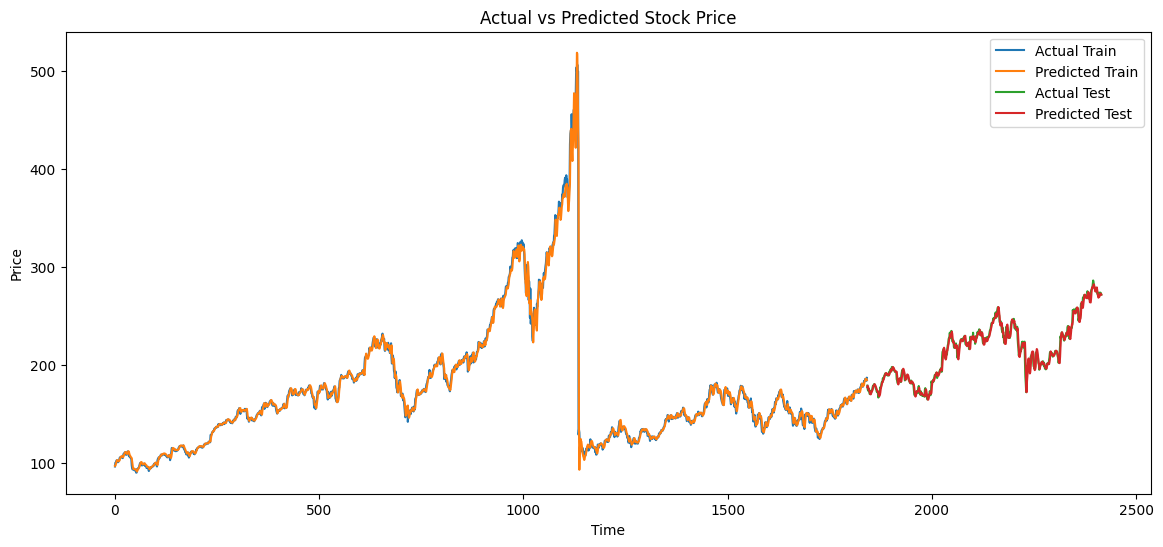

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

plt.plot(y_train_inv, label="Actual Train")
plt.plot(train_predict, label="Predicted Train")

plt.plot(
    range(len(y_train_inv), len(y_train_inv) + len(y_test_inv)),
    y_test_inv,
    label="Actual Test"
)

plt.plot(
    range(len(y_train_inv), len(y_train_inv) + len(test_predict)),
    test_predict,
    label="Predicted Test"
)

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Actual vs Predicted Stock Price")
plt.legend()
plt.show()


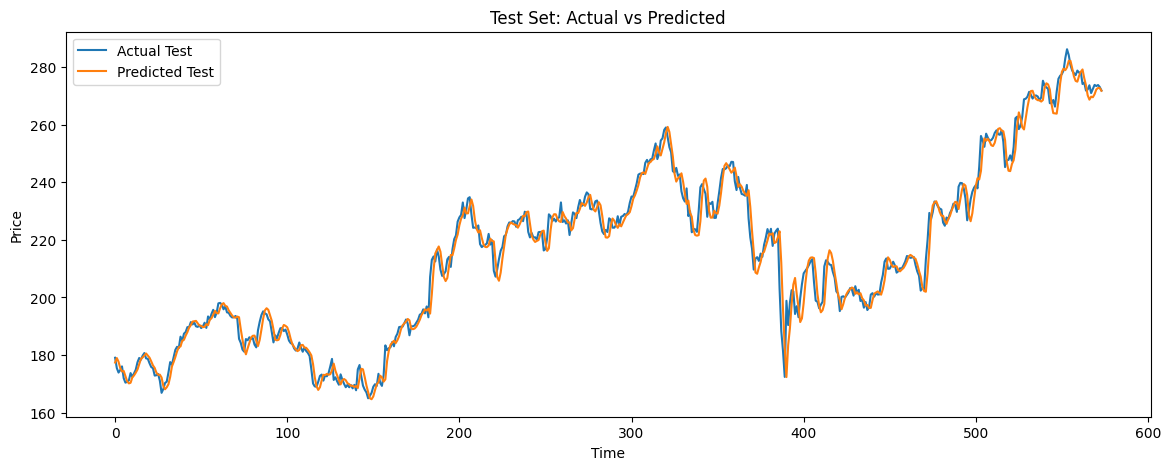

In [22]:
plt.figure(figsize=(14,5))

plt.plot(y_test_inv, label="Actual Test")
plt.plot(test_predict, label="Predicted Test")

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Test Set: Actual vs Predicted")
plt.legend()
plt.show()


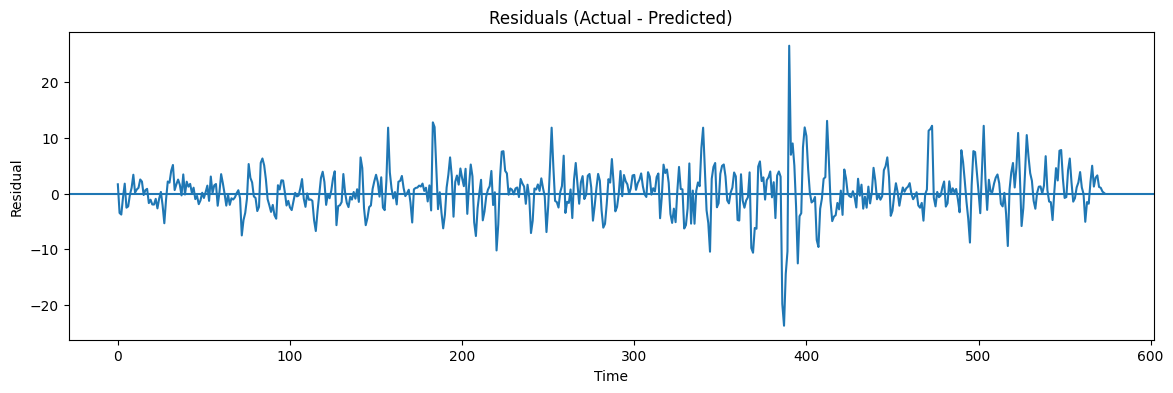

In [23]:
residuals = y_test_inv.flatten() - test_predict.flatten()

plt.figure(figsize=(14,4))
plt.plot(residuals)
plt.axhline(0)
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()


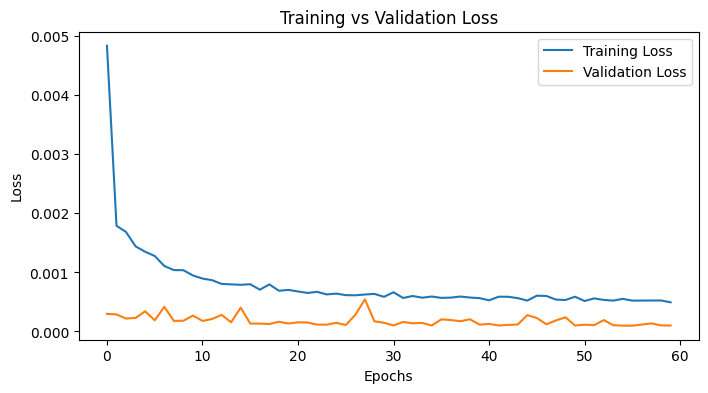

In [24]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


In [25]:
last_window = test_data[-time_step:]
last_window = last_window.reshape(1, time_step, 1)

next_day_pred = model.predict(last_window)
next_day_price = scaler.inverse_transform(next_day_pred)
print("Predicted next day price:", next_day_price[0][0])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted next day price: 270.09372


### Using Stacked LSTM

In [26]:
modelsta = Sequential()

# First LSTM layer (returns full sequence)
modelsta.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Second LSTM layer (returns final output)
modelsta.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

# Output layer (predict next Close price)
modelsta.add(Dense(1))

c:\Users\Arsh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)


# Complie the model
modelsta.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
modelsta.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = modelsta.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    verbose=1
)


Epoch 1/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 0.0145 - val_loss: 3.6971e-04
Epoch 2/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0033 - val_loss: 7.4434e-04
Epoch 3/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0019 - val_loss: 3.3479e-04
Epoch 4/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0011 - val_loss: 3.6764e-04
Epoch 5/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0014 - val_loss: 6.2779e-04
Epoch 6/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 7/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0015 - val_loss: 2.5125e-04
Epoch 8/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.2434e-04 - val_loss: 2.8422e-04
Epoch 9/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0020 - val_loss: 2.0218e-04
Epoch 10/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0012 - val_loss: 1.9203e-04
Epoch 11/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.8639e-04 - val_loss: 2.7298e-04
Epoch 12/60
58/

In [29]:
train_predict1 = modelsta.predict(X_train)
test_predict1  = modelsta.predict(X_test)

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [30]:
# Inverse scaling .
train_predict1 = scaler.inverse_transform(train_predict1)
test_predict1  = scaler.inverse_transform(test_predict1)

y_train_inv = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_inv  = scaler.inverse_transform(y_test.reshape(-1,1))


In [31]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict1))
print("RMSE:", rmse)
mse = mean_squared_error(y_test_inv, test_predict1)
print("MSE:", mse)

RMSE: 4.453526248880173
MSE: 19.833896049464702


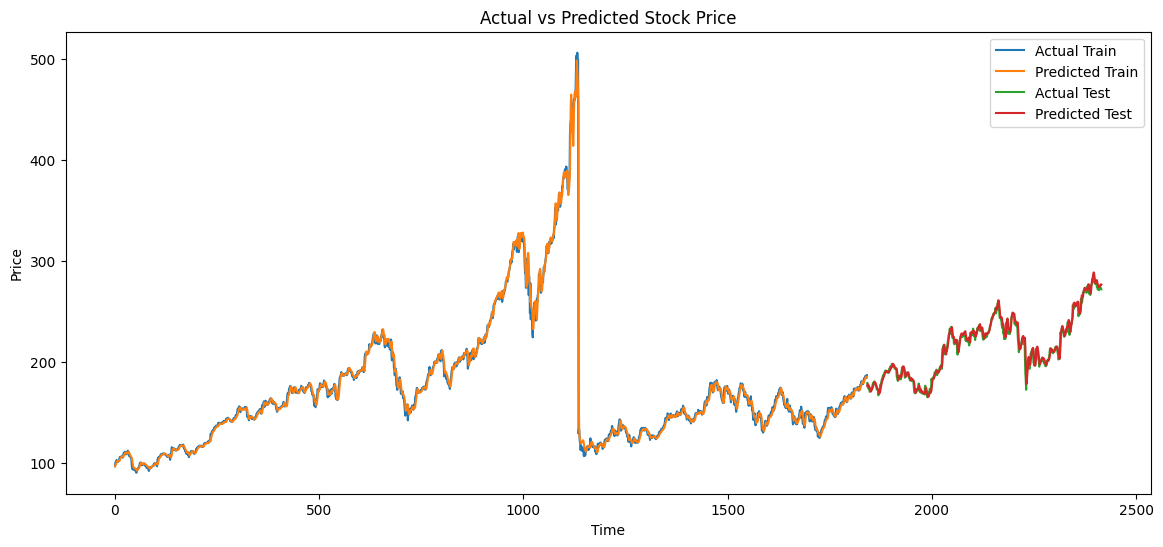

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

plt.plot(y_train_inv, label="Actual Train")
plt.plot(train_predict1, label="Predicted Train")

plt.plot(
    range(len(y_train_inv), len(y_train_inv) + len(y_test_inv)),
    y_test_inv,
    label="Actual Test"
)

plt.plot(
    range(len(y_train_inv), len(y_train_inv) + len(test_predict1)),
    test_predict1,
    label="Predicted Test"
)

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Actual vs Predicted Stock Price")
plt.legend()
plt.show()


In [33]:
last_window1 = test_data[-time_step:]
last_window1 = last_window1.reshape(1, time_step, 1)

next_day_pred1 = modelsta.predict(last_window1)
next_day_price1 = scaler.inverse_transform(next_day_pred1)
print("Predicted next day price:", next_day_price1[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted next day price: 275.41428
